In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import pickle
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
from natsort import natsorted

# Add function path
original_path = os.getcwd()
os.chdir(original_path)
function_path = '../functions/'
sys.path.append(function_path)

# Import custom functions
from analysis_function import *
from kcc_constrain_function import *
from Plot_function import *
from f1_0_H_sum_multi_region_constrain import *
from f_IMP import *
from f_schemes import *
from p_IMP_plot import *
import regionmask

In [3]:
# Your custom order
groups = {
    'North and Central America': ['GIC', 'NWN', 'NEN', 'WNA', 'CNA', 'ENA', 'NCA', 'SCA', 'CAR'],
    'South America': ['NWS', 'NSA', 'NES', 'SAM', 'SWS', 'SES', 'SSA'],
    'Europe': ['NEU', 'WCE', 'EEU', 'MED'],
    'Africa': ['SAH', 'WAF', 'CAF', 'NEAF', 'SEAF', 'WSAF', 'ESAF', 'MDG'],
    'Asia': ['RAR', 'WSB', 'ESB', 'RFE', 'WCA', 'ECA', 'TIB', 'EAS', 'ARP', 'SAS'],
    'Australasia': ['SEA', 'NAU', 'CAU', 'EAU', 'SAU', 'NZ'],
    'Antarctica': ['EAN', 'WAN'],
    'Global land': ['LSAT']

}

# Flatten region list in desired order
ordered_regions = [abbr for group in groups.values() for abbr in group]
ordered_groups = [group for group, regions in groups.items() for _ in regions]


In [4]:
def load_xr_pickle(filename):
    with open(filename, "rb") as f:
        return pickle.load(f)

path = '../saved_data/'
name = '6.0_LN_as_pseudo_IPM_Prior_posterier_Pseudo_warming_period_2016-2025_ref1850-1900.pkl'

prior_post_all = load_xr_pickle(path + name)


prior = prior_post_all["prior_all_schemes"]
post = prior_post_all["post_all_schemes"]
pseudo = prior_post_all["pseudo_warming"].sel(region=ordered_regions)

selected_large_ensembles = ['ACCESS-ESM1-5', 'CanESM5', 'MIROC6']

prior_post_7scheme = xr.concat([post, prior.mean('scheme').expand_dims(scheme = ['prior'])], dim = 'scheme').squeeze().sel(region=ordered_regions)
prior_post_7scheme = prior_post_7scheme.where(
    prior_post_7scheme['model_name'].isin(selected_large_ensembles),
    drop=True
)
pseudo = pseudo.where(
    pseudo['model_name'].isin(selected_large_ensembles),
    drop=True
)

prior_post_group = group_by_model_name(prior_post_7scheme, dim_name = 'model_name')

pseudo_group = group_by_model_name(pseudo, dim_name = 'model_name')
pseudo_group

[<xarray.DataArray 'pseudo_warming' (pseudo: 40, region: 47)> Size: 15kB
 array([[1.69754339, 2.20644174, 2.43374325, ..., 1.19220503, 1.33785305,
         1.45445681],
        [2.35247865, 2.4536971 , 2.36688165, ..., 0.9580478 , 1.12310736,
         1.52235052],
        [1.61438096, 1.83937781, 2.10546132, ..., 1.23537522, 2.084521  ,
         1.35882551],
        ...,
        [2.82429564, 2.8691468 , 2.83691735, ..., 1.32783353, 1.06880709,
         1.52717535],
        [1.50867846, 2.84537161, 1.83525428, ..., 1.32338101, 1.1886093 ,
         1.36199433],
        [2.29630817, 1.03685529, 1.97251639, ..., 0.82000155, 1.52506652,
         1.21797121]], shape=(40, 47))
 Coordinates:
   * pseudo        (pseudo) object 320B 'ACCESS-ESM1-5_r10i1p1f1' ... 'ACCESS-...
   * region        (region) <U4 752B 'GIC' 'NWN' 'NEN' ... 'EAN' 'WAN' 'LSAT'
     region_group  (region) <U25 5kB 'North and Central America' ... 'Global l...
     model_name    (pseudo) <U13 2kB 'ACCESS-ESM1-5' ... 'ACCESS-

### Calculation

### confidence ratio for each pseudo-world

In [5]:
path = '../saved_data/'

ln_mod_all = load_xr_pickle(path + '0.3.Large_ensembles.320runs.nonmasked.Tas.anomalies.46AR6regions_7cont_1glob_251years_1850-2100.pkl')

mod_ln_pseudo = change_ref(ln_mod_all, 1850, 1900).sel(year = slice(2016, 2025)).mean('year')

mod_ln_pseudo = mod_ln_pseudo.assign_coords(
    region = ("region", mod_ln_pseudo["abbrevs"].values)
)

mod_ln_pseudo = mod_ln_pseudo.where(
    mod_ln_pseudo['model_name'].isin(selected_large_ensembles),
    drop=True
)


In [6]:

mod_ln_pseudo_selected = mod_ln_pseudo.where(
    mod_ln_pseudo['model_name'].isin(selected_large_ensembles),
    drop=True
)

mod_ln_pseudo_selected

<xarray.DataArray 'TS' (model_run: 140, region: 54)> Size: 60kB
array([[1.69754339, 2.20644174, 2.43374325, ..., 0.9911166 , 1.23445288,
        1.45445681],
       [2.35247865, 2.4536971 , 2.36688165, ..., 1.00866892, 1.00592631,
        1.52235052],
       [1.61438096, 1.83937781, 2.10546132, ..., 1.04614498, 1.48168533,
        1.35882551],
       ...,
       [1.95638032, 2.41220712, 2.45092565, ..., 0.67768063, 0.74821639,
        1.13060181],
       [1.60517235, 1.90334019, 2.4320599 , ..., 0.64225624, 0.86384908,
        1.17814993],
       [2.04527548, 1.73264524, 2.81180167, ..., 0.79067133, 0.55468811,
        1.32449397]], shape=(140, 54))
Coordinates:
  * model_run   (model_run) <U23 13kB 'ACCESS-ESM1-5_r10i1p1f1' ... 'MIROC6_r...
    model_name  (model_run) <U13 7kB 'ACCESS-ESM1-5' ... 'MIROC6'
    abbrevs     (region) <U4 864B 'GIC' 'NWN' 'NEN' 'WNA' ... 'AU' 'ANT' 'LSAT'
    names       (region) <U25 5kB 'Greenland/Iceland' ... 'Global Land'
  * region      (region) <U4 864B 'GIC' 'NWN' 'NEN' 'WNA' ... 'AU' 'ANT' 'LSAT'

In [7]:
pseudo_mean_smoothed = mod_ln_pseudo.groupby('model_name').mean()
prior_post_group = prior_post_group

n_scheme = len(prior_post_group[0]['scheme'])
sq_errors_all = []
# for pseudo_id in range(len(pseudo_mean_smoothed)):
for pseudo_id in range(len(pseudo_mean_smoothed)):

    # reference pseudo mean
    pseudo_ref = pseudo_mean_smoothed[pseudo_id]
    post_mean = (
        prior_post_group[pseudo_id]
        .isel(scheme=slice(0, n_scheme))
        .sel(quantile='mean')
    )


    sq_errors = (post_mean - pseudo_ref)**2
    magnitude = pseudo_mean_smoothed[pseudo_id]
    scaled_sq_errors = sq_errors / (magnitude**2)

    # print(sq_errors)
    sq_errors_all.append(scaled_sq_errors)


sq_errors_all = xr.concat(sq_errors_all, dim = 'pseudo')

# n_pseudo = len(mod_ln_pseudo['model_run'])

# scaled_rmse_all = np.sqrt(sq_errors_all.sum(dim = 'pseudo')/ n_pseudo)

# scaled_rmse_all

# confidence_all = 1/(scaled_rmse_all)

In [8]:
aa = sq_errors_all.assign_coords(pseudo=mod_ln_pseudo['model_name'].values).groupby('pseudo').mean().mean('pseudo')

scaled_rmse_all = np.sqrt(aa)

scaled_rmse_all

confidence_all = 1/(scaled_rmse_all).assign_coords(scheme = sq_errors_all['scheme'])

/var/folders/jt/kr53pz_j4x3d_32xbfb7pkd87_b0mf/T/ipykernel_19343/2845009297.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  base = cm.get_cmap(name)


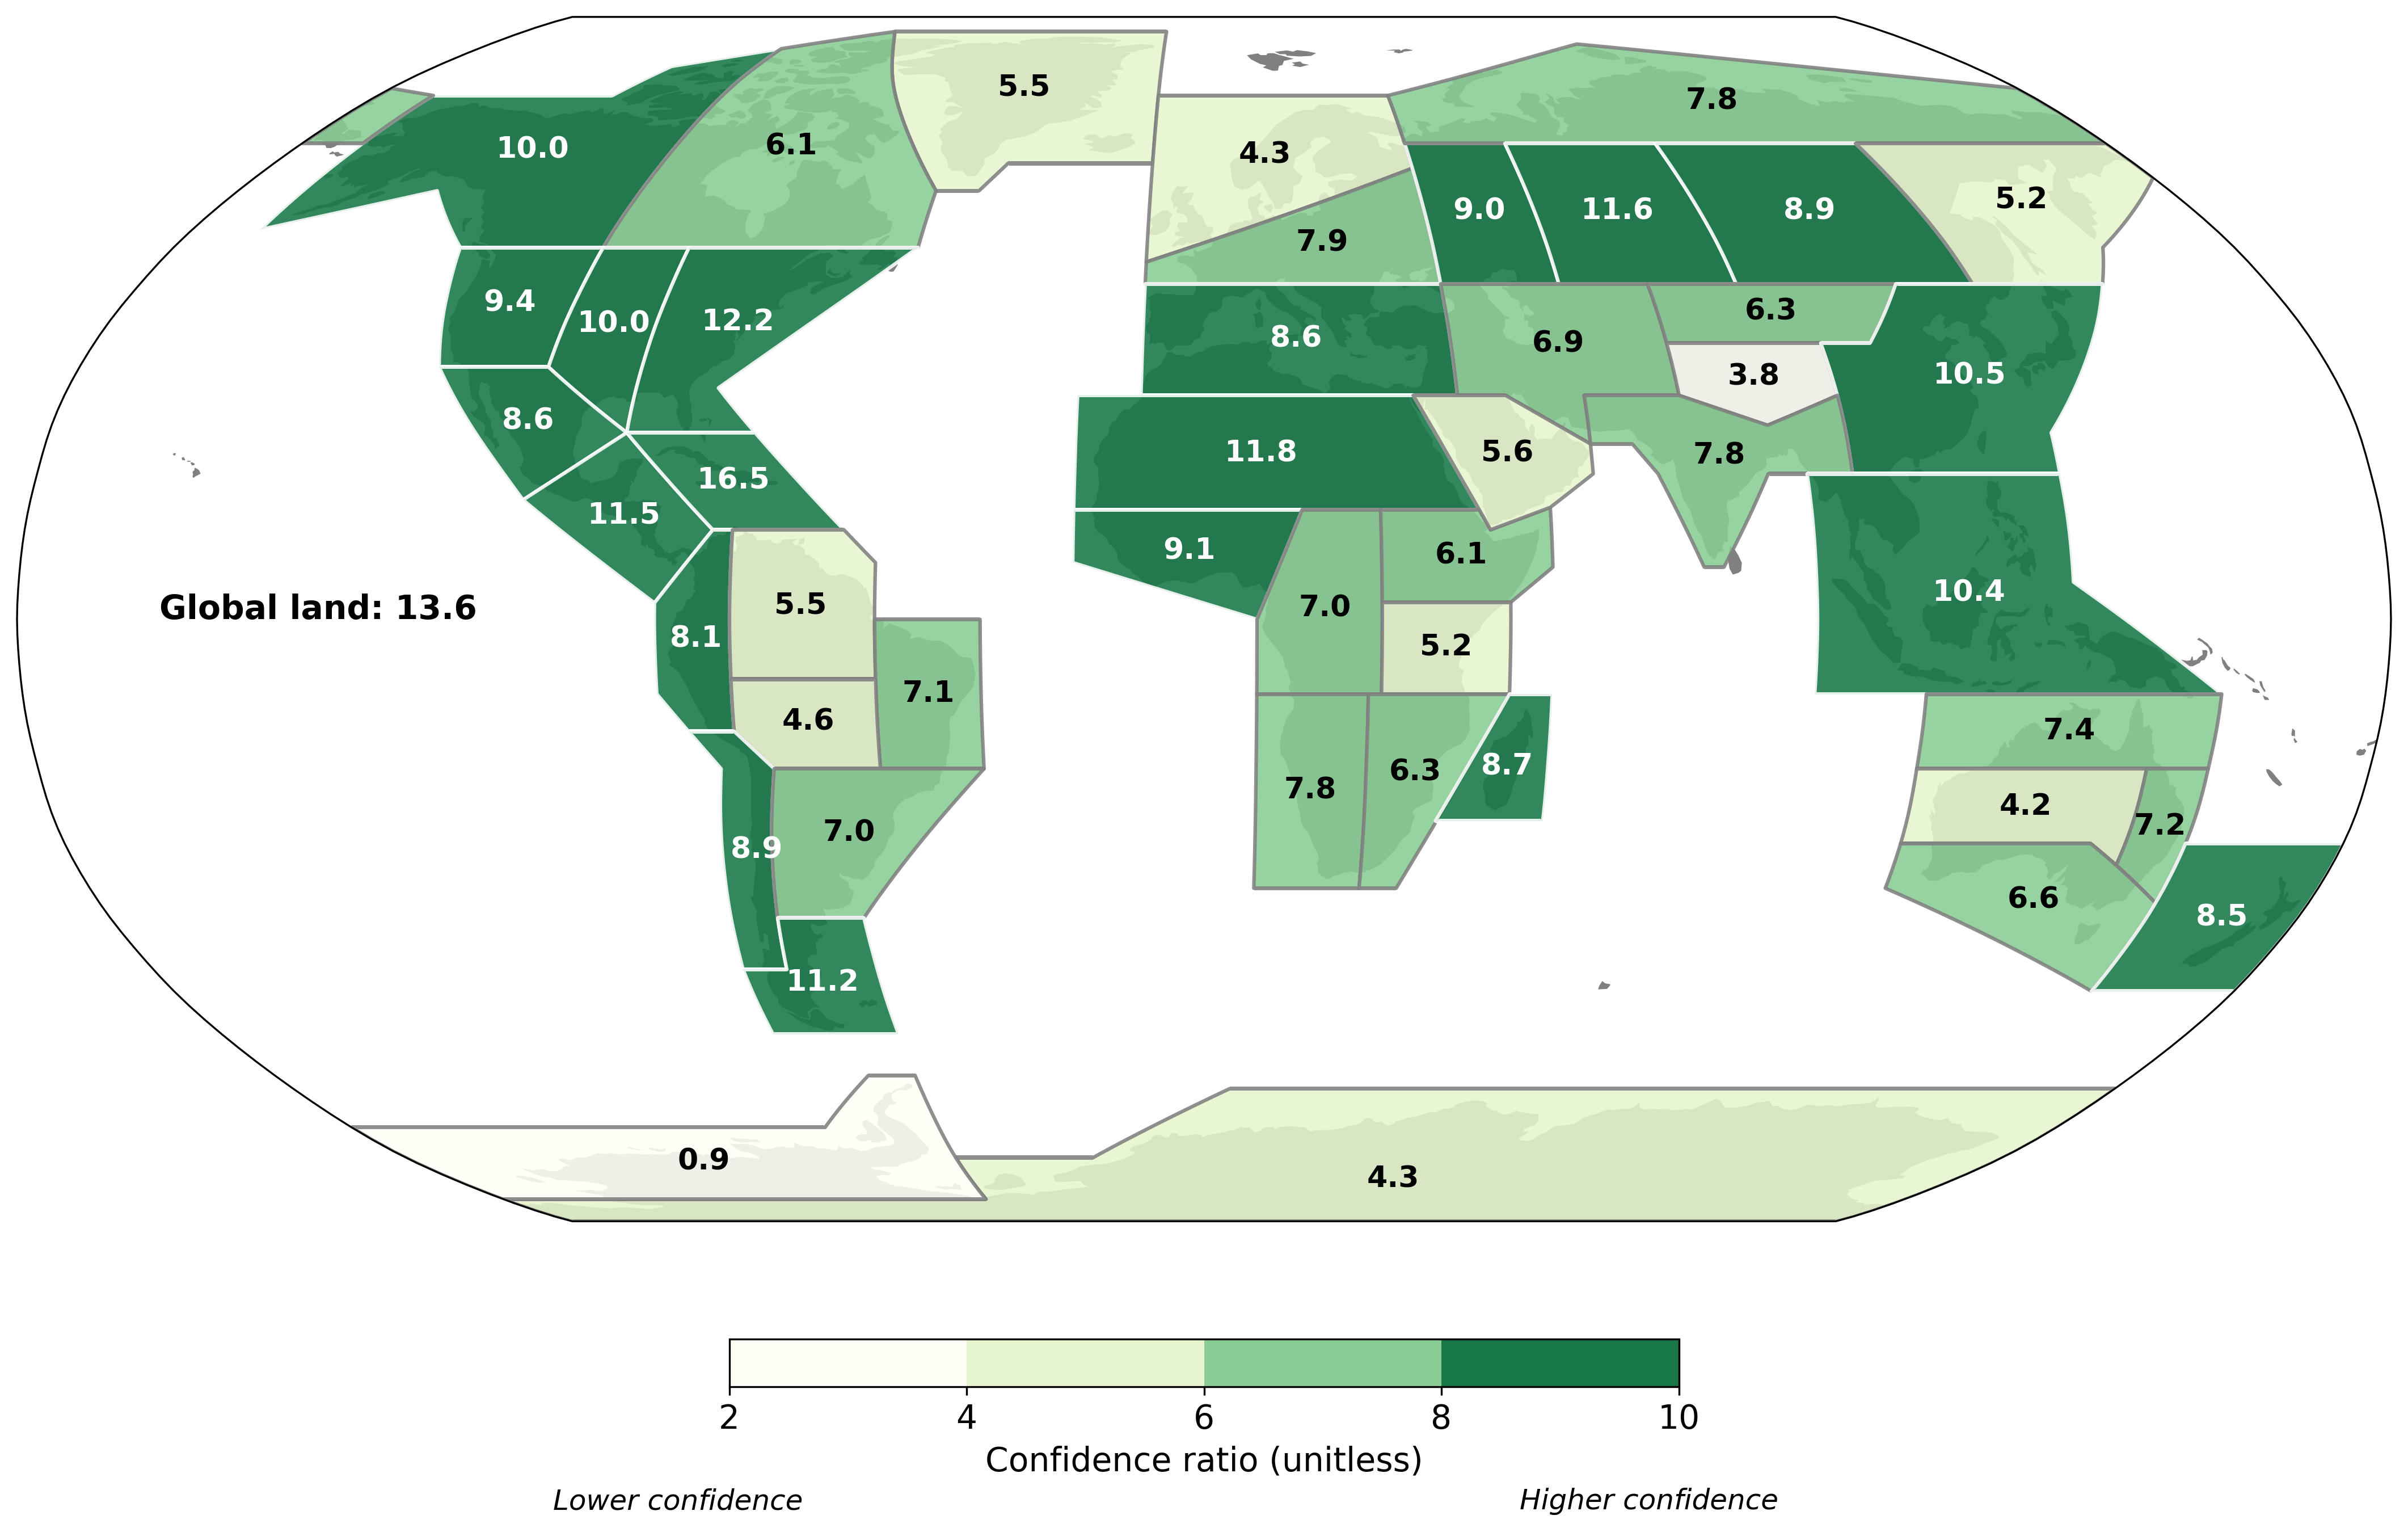

In [10]:
confidence_best = confidence_all.sel(scheme = 'global_region').isel(region = slice(0, 46))
global_value = confidence_all.sel(scheme = 'global_region').isel(region = 46)

unit = ' '
import matplotlib.colors as colors
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.colors as mcolors
import matplotlib.patheffects as pe
import cartopy.crs as ccrs
import cartopy.feature as cfeature
# Shared colorbar
cmap = sns.color_palette("OrRd", as_cmap=True)

# cmap = LinearSegmentedColormap.from_list("red_white", ["white", "#008000"])
def modify_cmap(name='YlGn', start=0.1, end=0.9, gamma=0.8, white_strength=0.3):
    """
    white_strength = 0 → no whitening
    white_strength = 1 → pure white at start
    """
    base = cm.get_cmap(name)
    colors = base(np.linspace(start, end, 256))[:, :3] ** gamma
    
    # Blend first colors toward white
    white = np.array([1, 1, 1])
    for i in range(len(colors)):
        blend_factor = (1 - i / (len(colors)-1)) * white_strength
        colors[i] = (1-blend_factor)*colors[i] + blend_factor*white
    
    return ListedColormap(colors)


cmap = modify_cmap('YlGn', start=0.0, end=0.95, gamma=1.0, white_strength=0.7)

colors_array = cmap(np.linspace(0, 1, 256))
truncated_colors = colors_array[0:230]
truncated_cmap = colors.LinearSegmentedColormap.from_list('truncated_YlOrBr', truncated_colors)

# --- Plot panels ---
fig, axes = plt.subplots(1,1, figsize=(18, 18), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)

axes.set_global()
# axes.coastlines(linewidth=0.5)

bounds = np.arange(2, 12, 2)
norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=256, extend='neither')

norm0 = plot_ar6_region_data_on_ax_new(axes, confidence_best, cmap=truncated_cmap, norm=norm, decimals=1, region_shifts = {
    "SWS": (2.0, 0),   # (x_shift, y_shift)
    "EAU": (-0.5, 0) # another example
})


axes.text(
            0.06, 0.5,
            f"Global land: {global_value:.1f}{unit}",   # unit inserted here
            transform=axes.transAxes,
            fontsize=14,
            fontweight='bold',
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=4)
        )


# axes.set_title("Confidence map (Warming magnitude / estimation error (RMSE) in 2016-2025 ref. to 1850-1900)", fontsize=14, fontweight='bold', loc='left')


# --- Shared colorbar ---
# Use a ScalarMappable with the colormap and norm
sm = plt.cm.ScalarMappable(cmap=truncated_cmap, norm=norm0)
sm.set_array([])  # required for ScalarMappable

cb = fig.colorbar(sm, ax=axes, orientation='horizontal', pad=0.05, shrink=0.4,)
cb.ax.tick_params(labelsize=14)

cb.set_label("Confidence ratio (unitless)", fontsize=14)

# Add qualifiers for lower and higher confidence
fig.text(0.3, 0.17, 'Lower confidence', fontsize=12, ha='left', style='italic')
fig.text(0.7, 0.17, 'Higher confidence', fontsize=12, ha='right', style='italic')

plt.show()
# fig.savefig('./saved_figures/Fig_2.pdf', dpi=300, bbox_inches='tight')


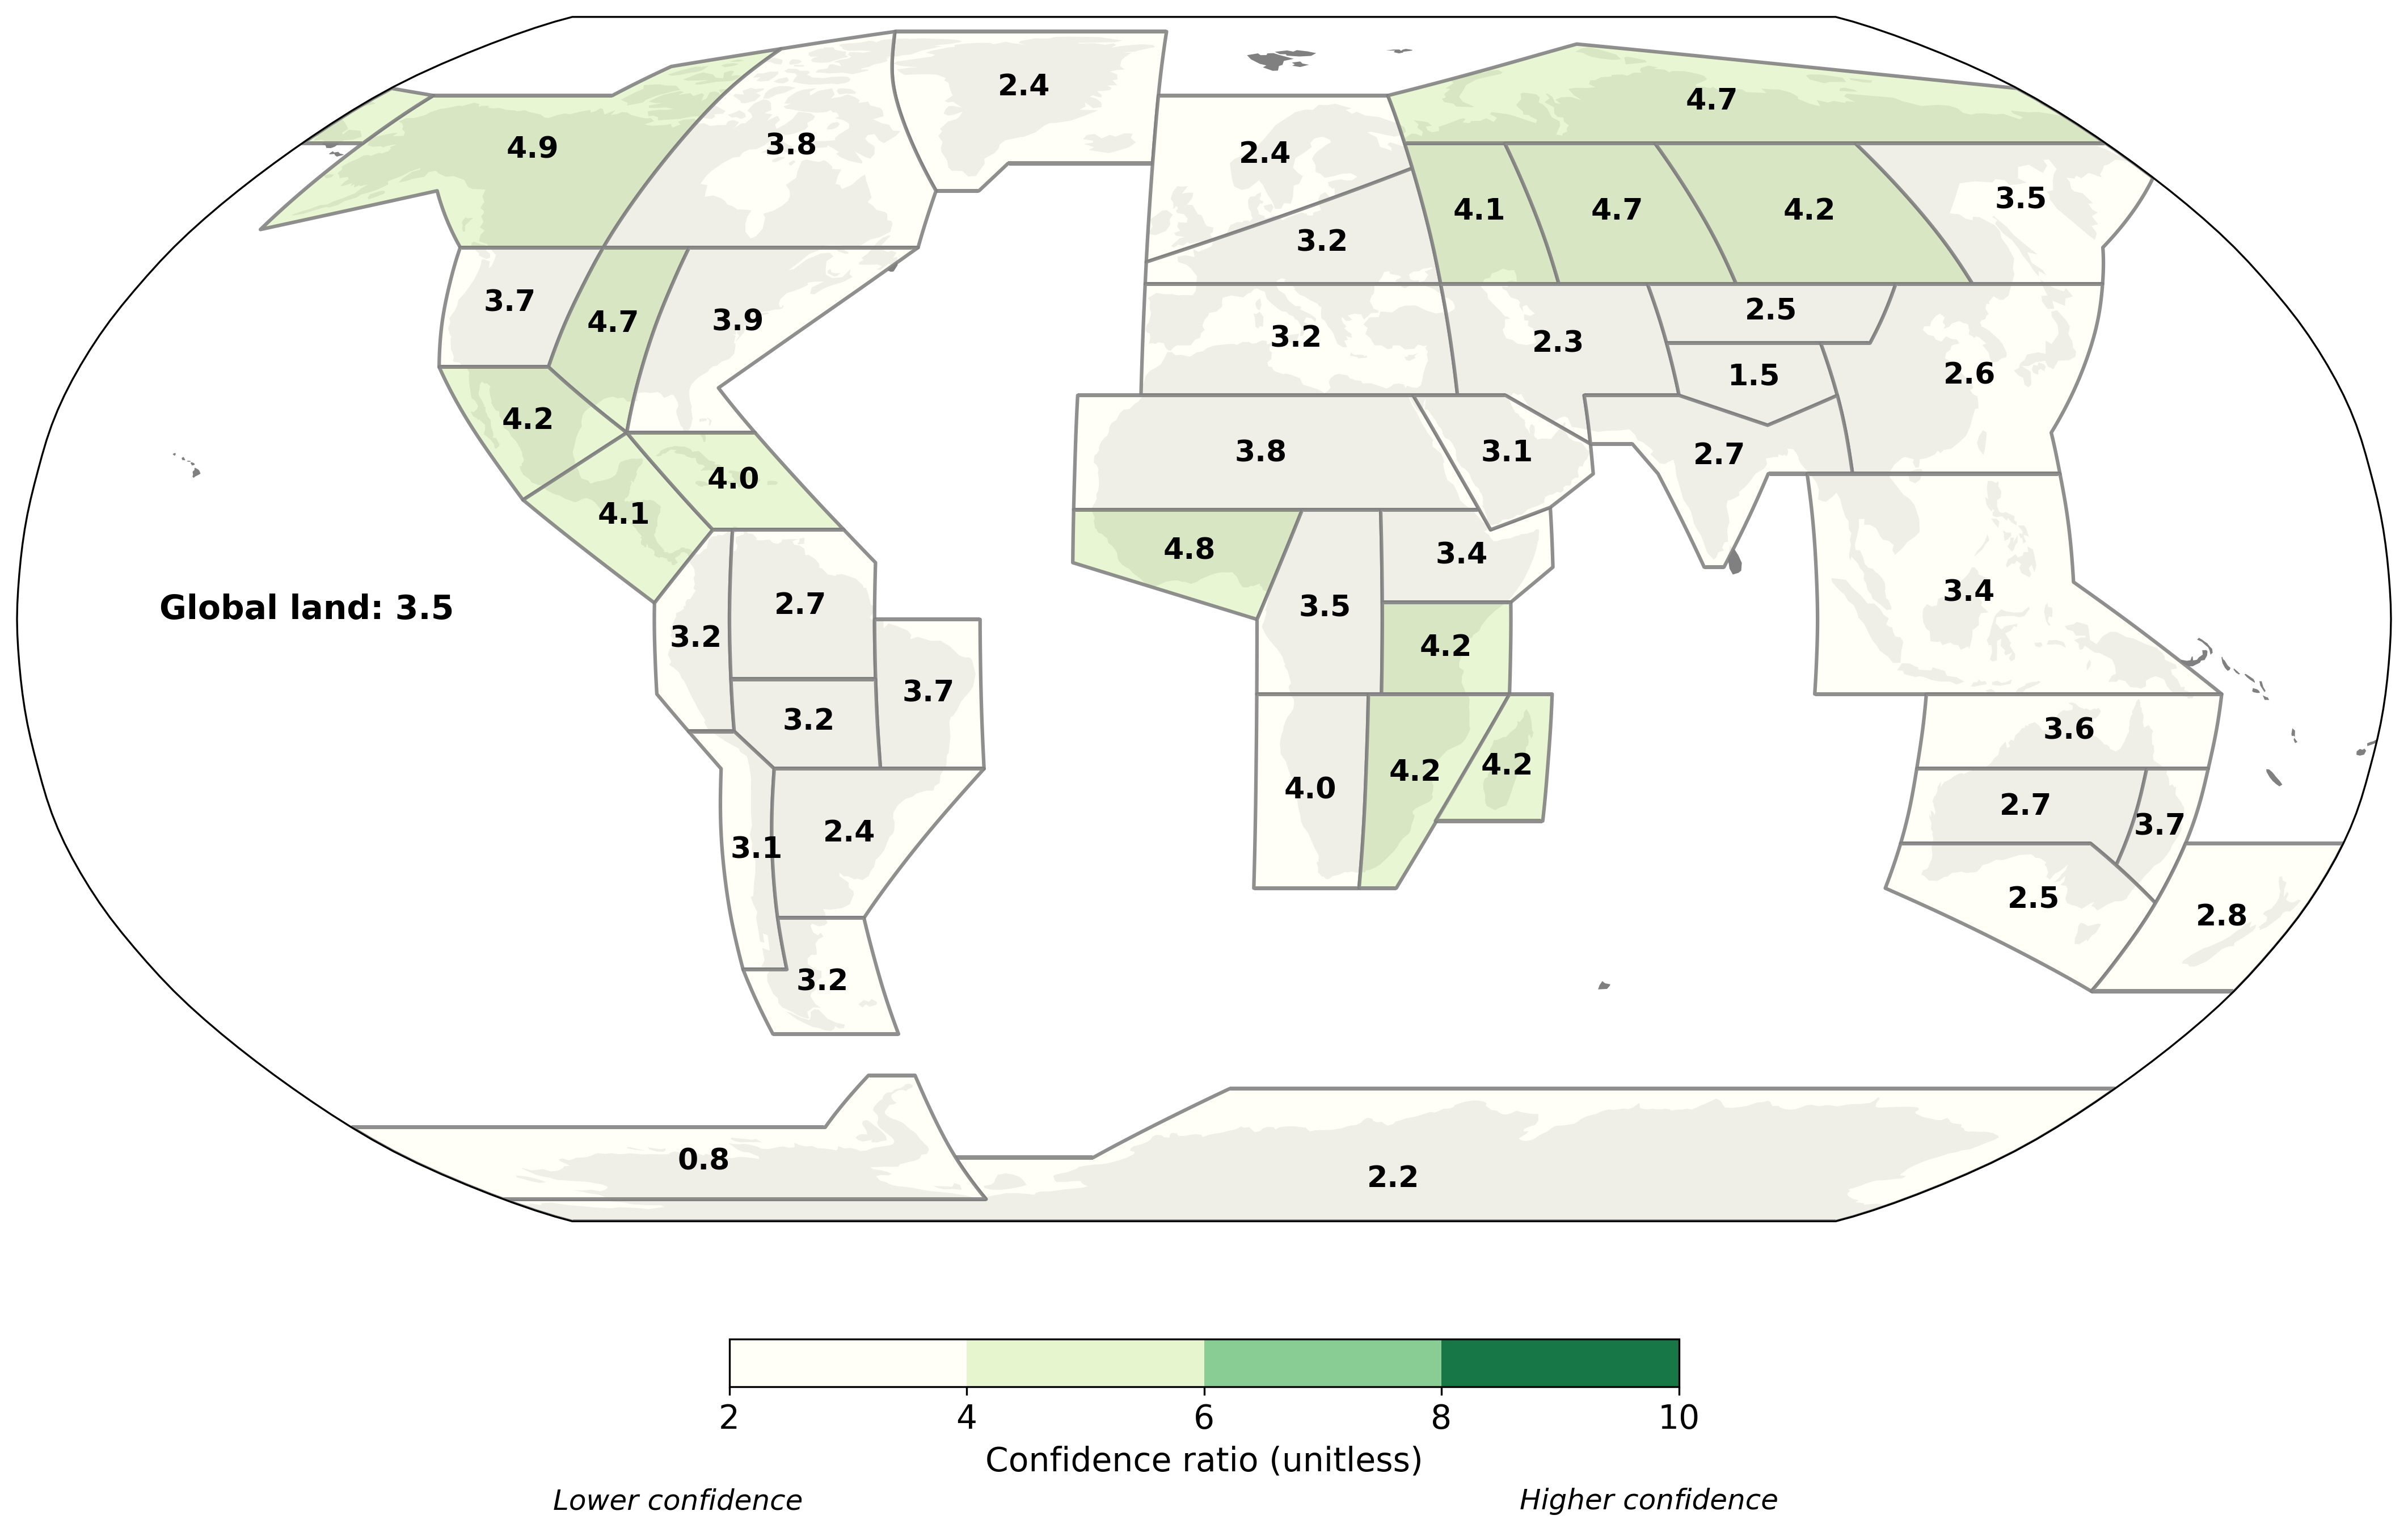

In [11]:
confidence_prior = confidence_all.sel(scheme = 'prior').isel(region = slice(0, 46))
global_prior = confidence_all.sel(scheme = 'prior').isel(region = 46)

# --- Plot panels ---
fig, axes = plt.subplots(1,1, figsize=(18, 18), subplot_kw={'projection': ccrs.Robinson()}, dpi=300)

axes.set_global()
# axes.coastlines(linewidth=0.5)

norm = mcolors.BoundaryNorm(boundaries=bounds, ncolors=256, extend='neither')

norm0 = plot_ar6_region_data_on_ax_new(axes, confidence_prior, cmap=truncated_cmap, norm=norm, decimals=1, region_shifts = {
    "SWS": (2.0, 0),   # (x_shift, y_shift)
    "EAU": (-0.5, 0) # another example
})

# axes.set_title("Confidence map (Warming magnitude / estimation error (RMSE) in 2016-2025 ref. to 1850-1900)", fontsize=14, fontweight='bold', loc='left')

axes.text(
            0.06, 0.5,
            f"Global land: {global_prior:.1f}{unit}",   # unit inserted here
            transform=axes.transAxes,
            fontsize=14,
            fontweight='bold',
            color='black',
            bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', pad=4)
        )

# --- Shared colorbar ---
# Use a ScalarMappable with the colormap and norm
sm = plt.cm.ScalarMappable(cmap=truncated_cmap, norm=norm0)
sm.set_array([])  # required for ScalarMappable

cb = fig.colorbar(sm, ax=axes, orientation='horizontal', pad=0.05, shrink=0.4,)
cb.ax.tick_params(labelsize=14)


cb.set_label("Confidence ratio (unitless)", fontsize=14)

# Add qualifiers for lower and higher confidence
fig.text(0.3, 0.17, 'Lower confidence', fontsize=12, ha='left', style='italic')
fig.text(0.7, 0.17, 'Higher confidence', fontsize=12, ha='right', style='italic')

plt.show()
# fig.savefig('./saved_figures/ED_Fig7.pdf', dpi=300, bbox_inches='tight')


### confidence ratio for each pseudo-world

In [12]:
# Step 1: assign model name coordinates to the selected realizations
sq_errors_labelled = sq_errors_all.assign_coords(pseudo=mod_ln_pseudo['model_name'].values)

# Step 2: average sq_errors over realizations within each selected model
sq_errors_per_model = sq_errors_labelled.groupby('pseudo').mean()  
# shape: (model=3, scheme, region)

# Step 3: take sqrt then inverse — same order as original
scaled_rmse_per_model = np.sqrt(sq_errors_per_model)
confidence_per_model = 1 / scaled_rmse_per_model
# shape: (model=3, scheme, region)

confidence_per_model = confidence_per_model.assign_coords(scheme = sq_errors_all['scheme'])

In [13]:
# --- Step 1: Find best and worst pseudo models ---
# Use mean confidence ratio across land regions (exclude last index if it's global)
cr_constrained = confidence_per_model.isel(scheme=0)  # adjust scheme index
cr_prior       = confidence_per_model.isel(scheme=1)  # adjust scheme index

# Mean across regions for each selected pseudo model
cr_constrained_median = cr_constrained.median('region')  # shape (pseudo=3,)
cr_prior_median       = cr_prior.median('region')

# bias = cr_constrained_median - cr_prior_median

# Find best and worst pseudo indices based on constrained scheme
best_idx  = int(cr_constrained_median.argmax('pseudo'))
worst_idx = int(cr_constrained_median.argmin('pseudo'))

best_model  = str(cr_constrained_median.pseudo.values[best_idx])
worst_model = str(cr_constrained_median.pseudo.values[worst_idx])

print(f"Best  pseudo model: {best_model}  (median CR = {float(cr_constrained_median[best_idx]):.2f})")
print(f"Worst pseudo model: {worst_model} (median CR = {float(cr_constrained_median[worst_idx]):.2f})")


Best  pseudo model: ACCESS-ESM1-5  (median CR = 10.10)
Worst pseudo model: CanESM5 (median CR = 7.53)


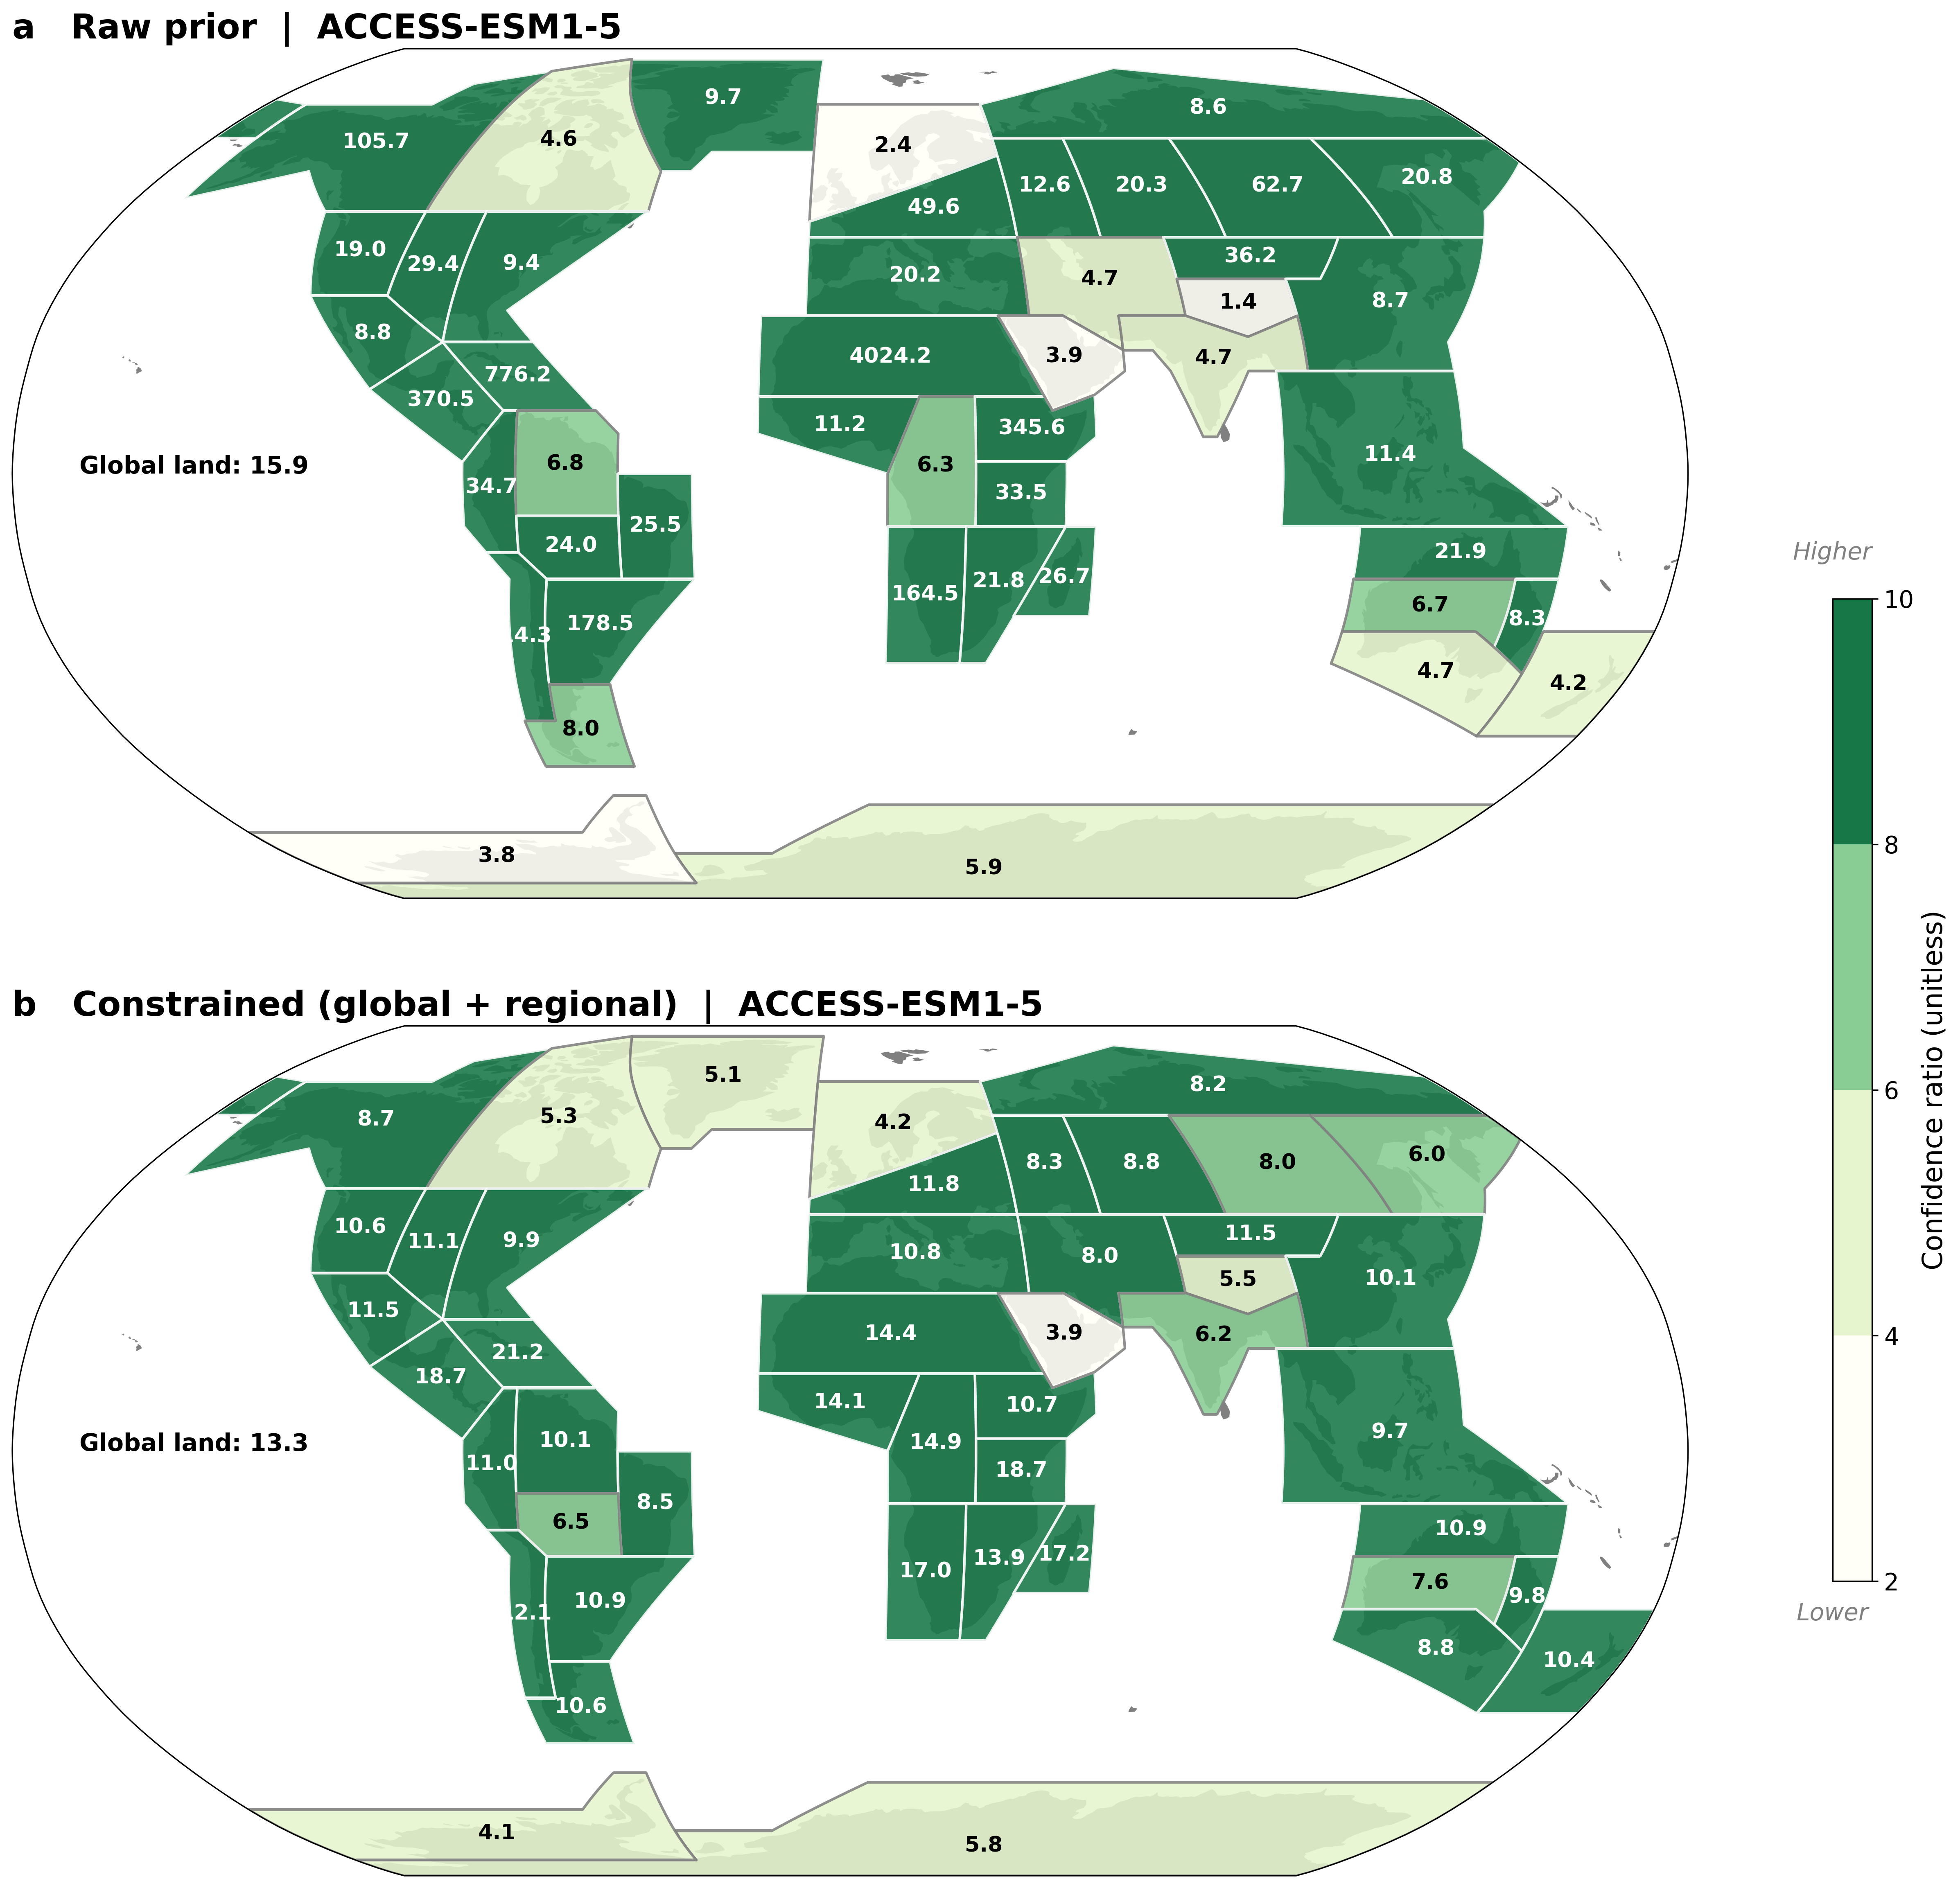

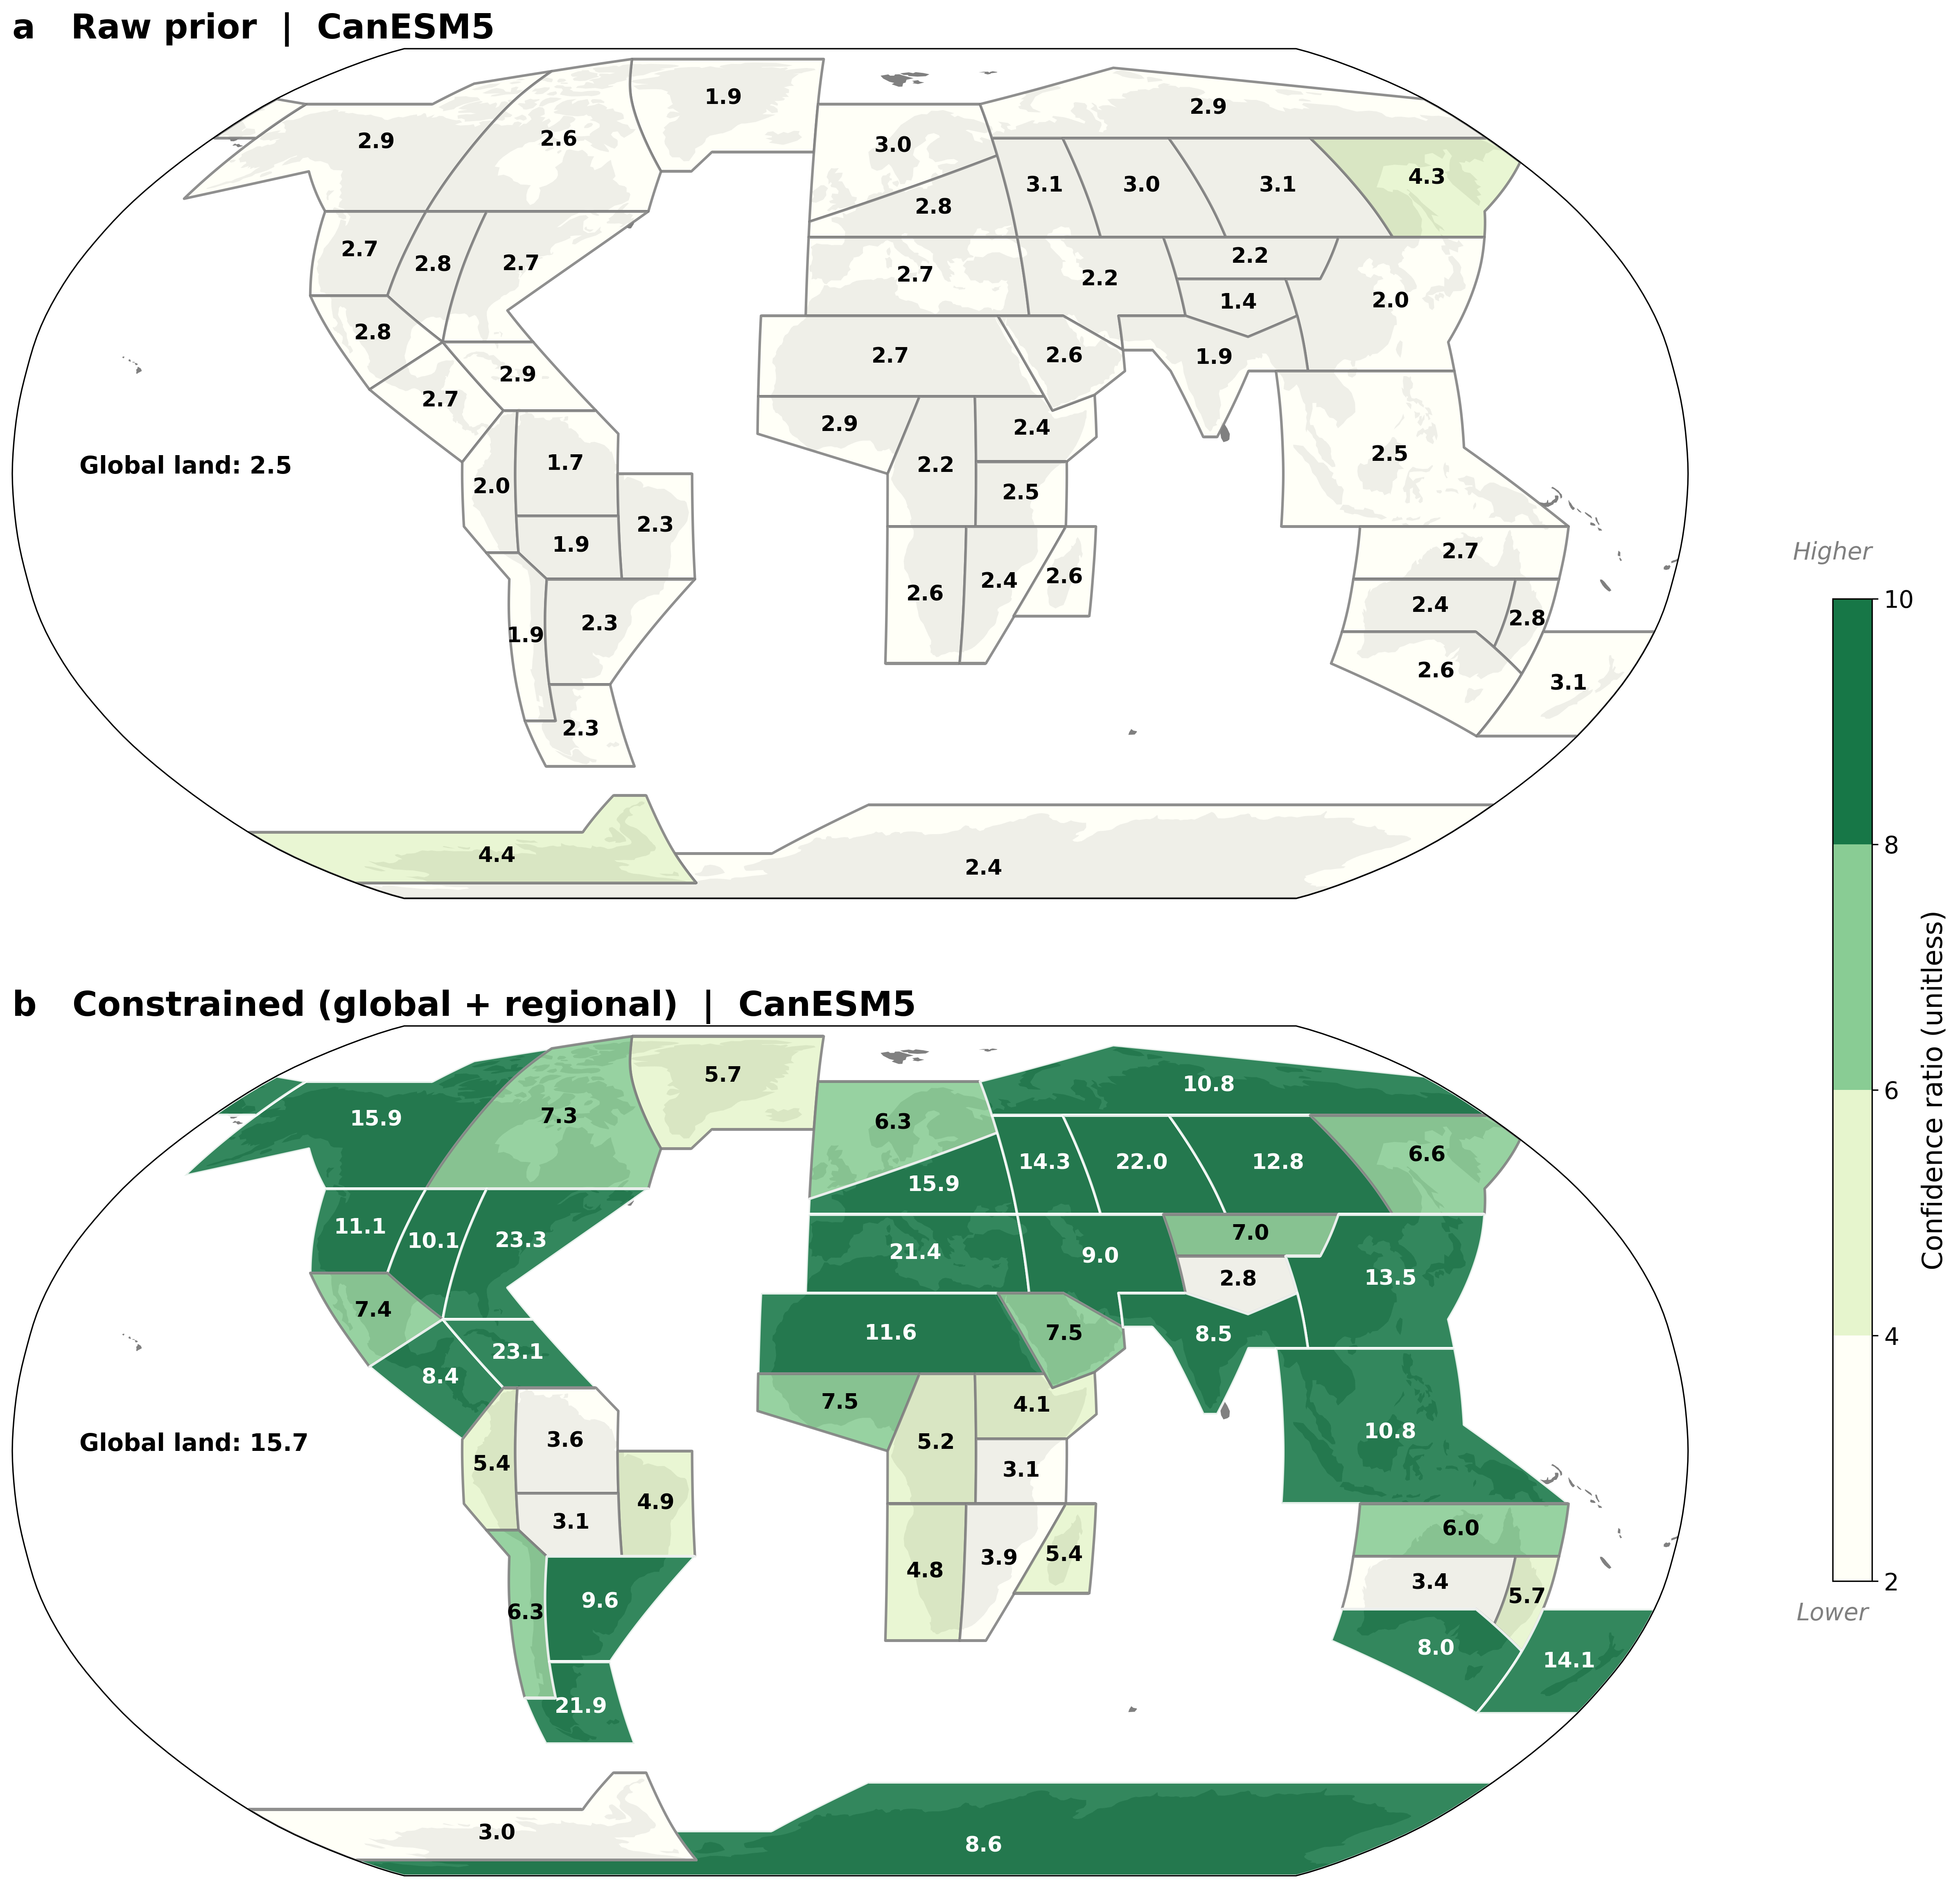

In [14]:
from Plot_function import *

# --- Extract data for best and worst models ---
panels = {
    'best': {
        'prior':       confidence_per_model.isel(scheme=1).sel(pseudo=best_model).isel(region=slice(0, 46)),
        'constrained': confidence_per_model.isel(scheme=0).sel(pseudo=best_model).isel(region=slice(0, 46)),
    },
    'worst': {
        'prior':       confidence_per_model.isel(scheme=1).sel(pseudo=worst_model).isel(region=slice(0, 46)),
        'constrained': confidence_per_model.isel(scheme=0).sel(pseudo=worst_model).isel(region=slice(0, 46)),
    },
}

panels_global = {
    'best': {
        'prior':       float(confidence_per_model.isel(scheme=1, region=46).sel(pseudo=best_model)),
        'constrained': float(confidence_per_model.isel(scheme=0, region=46).sel(pseudo=best_model)),
    },
    'worst': {
        'prior':       float(confidence_per_model.isel(scheme=1, region=46).sel(pseudo=worst_model)),
        'constrained': float(confidence_per_model.isel(scheme=0, region=46).sel(pseudo=worst_model)),
    },
}

panel_labels = {
    'best': {
        'prior':       f"a   Raw prior  |  {best_model}",
        'constrained': f"b   Constrained (global + regional)  |  {best_model}",
    },
    'worst': {
        'prior':       f"a   Raw prior  |  {worst_model}",
        'constrained': f"b   Constrained (global + regional)  |  {worst_model}",
    },
}

figure_num = {
    'best': 1,
    'worst': 2,
    }
# --- Colormap and norm (confidence ratio) ---
bounds = np.arange(2, 12, 2)
norm   = mcolors.BoundaryNorm(boundaries=bounds, ncolors=256, extend='neither')

# Reuse your truncated_cmap / cmap_with_alpha from existing code
# or define a fresh one here if needed

# --- Plot one figure per pseudo model ---
for pseudo_key, model_name in [('best', best_model), ('worst', worst_model)]:

    data_dict_plot = {
        'a': panels[pseudo_key]['prior'],
        'b': panels[pseudo_key]['constrained'],
    }
    global_values_plot = {
        'a': panels_global[pseudo_key]['prior'],
        'b': panels_global[pseudo_key]['constrained'],
    }
    label_dict = {
        'a': panel_labels[pseudo_key]['prior'],
        'b': panel_labels[pseudo_key]['constrained'],
    }

    fig, axes = plt.subplots(
        2, 1, figsize=(16, 16),
        subplot_kw={'projection': ccrs.Robinson()},
        dpi=300
    )

    for ax, (panel_key, data) in zip(axes, data_dict_plot.items()):
        plot_panel(
            ax, data,
            label_dict[panel_key],
            truncated_cmap, norm,
            decimals=1,
            global_value=global_values_plot[panel_key],
            unit='',   # confidence ratio is unitless
            fontsize = 20, fontweight='bold'
        )

    # Shared colorbar
    sm = plt.cm.ScalarMappable(cmap=truncated_cmap, norm=norm)
    sm.set_array([])

    cbar_ax = fig.add_axes([0.98, 0.2, 0.02, 0.5])
    cb = fig.colorbar(sm, cax=cbar_ax)
    cb.ax.tick_params(labelsize=14)
    cb.set_label("Confidence ratio (unitless)", fontsize=16)

    # Add qualifiers
    fig.text(0.98, 0.18, 'Lower', fontsize=14, ha='center', style='italic', color='gray')
    fig.text(0.98, 0.72, 'Higher', fontsize=14, ha='center', style='italic', color='gray')

    fig.subplots_adjust(left=0.02, right=0.94, top=0.98, bottom=0.05, hspace=0.15)


    plt.show()

    # fig.savefig(
    #     f'./saved_figures/Fig_S{figure_num[pseudo_key]}.pdf',
    #     dpi=300, bbox_inches='tight'
    # )

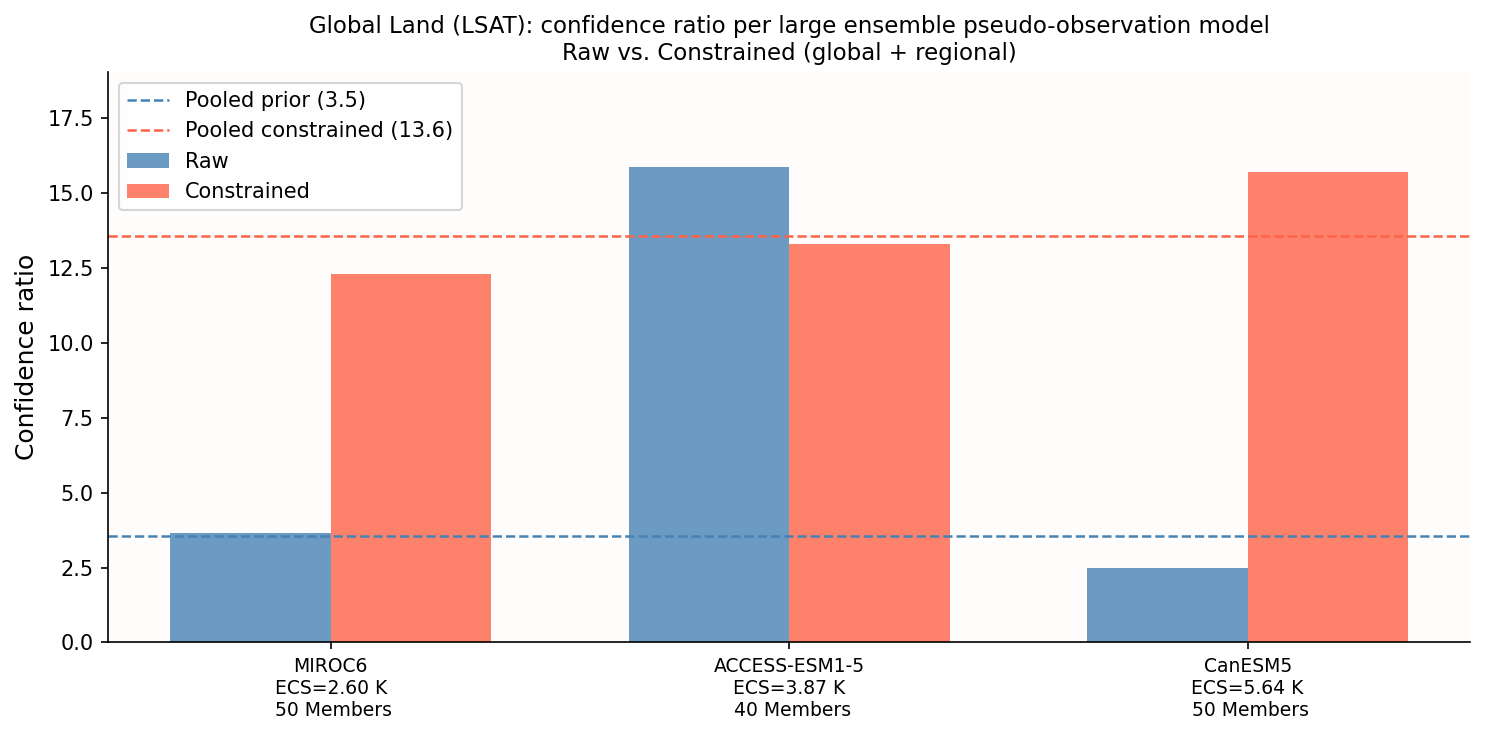

In [16]:
# --- Extract LSAT for the selected large ensembles ---

cr_lsat = confidence_per_model.sel(region='LSAT').sel(
    pseudo=selected_large_ensembles
)  # shape (scheme=2, pseudo=3)

scheme_names = list(cr_lsat.scheme.values)
pseudo_names_raw = [p.split('_run')[0] if '_run' in p else p 
                    for p in cr_lsat.pseudo.values]  # strip run suffix for readability

# ECS values for the known CMIP6 models (used to order the figure)
ecs_lookup = {
    'ACCESS-ESM1-5': 3.87,
    'CESM2': 5.2,
    'CanESM5': 5.64,
    'MIROC-ES2L': 2.7,
    'MIROC6': 2.60,
    'MPI-ESM1-2-LR': 3.0,
}

# Member count for each selected model
member_counts = [
    int((mod_ln_pseudo['model_name'].values == name).sum())
    for name in pseudo_names_raw
]

# Sort the selected large ensembles from low to high ECS
pseudo_ecs = [ecs_lookup.get(name, np.nan) for name in pseudo_names_raw]
order = np.argsort(pseudo_ecs)

pseudo_names = [pseudo_names_raw[i] for i in order]
cr_prior = cr_lsat.isel(scheme=1).values[order]  # adjust index if needed
cr_constrained = cr_lsat.isel(scheme=0).values[order]
ecs_ordered = [pseudo_ecs[i] for i in order]
member_counts_ordered = [member_counts[i] for i in order]

# Make the x-axis labels include the ECS value and member count directly in the model name
x_labels = [
    f"{name}\nECS={ecs:.2f} K\n {count} Members"
    if np.isfinite(ecs) else f"{name}\n {count} Members"
    for name, ecs, count in zip(pseudo_names, ecs_ordered, member_counts_ordered)
]

# --- Plot ---
fig, ax = plt.subplots(figsize=(10, 5), dpi=150)
ax.set_facecolor('#fefdfb')

x = np.arange(len(pseudo_names))
width = 0.35

bars1 = ax.bar(x - width/2, cr_prior, width, label='Raw', color='steelblue', alpha=0.8)
bars2 = ax.bar(x + width/2, cr_constrained, width, label='Constrained', color='tomato', alpha=0.8)

# Add pooled confidence ratio as horizontal reference lines
pooled_prior = float(confidence_all.sel(scheme='prior', region='LSAT'))
pooled_constrained = float(confidence_all.isel(scheme=0, region=46))

ax.axhline(pooled_prior, color='steelblue', linestyle='--', linewidth=1.2,
           label=f'Pooled prior ({pooled_prior:.1f})')
ax.axhline(pooled_constrained, color='tomato', linestyle='--', linewidth=1.2,
           label=f'Pooled constrained ({pooled_constrained:.1f})')

ax.set_xticks(x)
ax.set_xticklabels(x_labels, rotation=0, ha='center', fontsize=9)
ax.set_ylabel('Confidence ratio', fontsize=12)
ax.set_title('Global Land (LSAT): confidence ratio per large ensemble pseudo-observation model\n'
             'Raw vs. Constrained (global + regional)', fontsize=11)
ax.legend(fontsize=10)
ax.set_ylim(0, max(cr_prior.max(), cr_constrained.max()) * 1.2)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../saved_figures/Fig.R3.pdf', dpi=300, bbox_inches='tight')
plt.show()